# Individual analytic task: Concentration of team scoring
**Student:** MD Abid Hossain Fahim  
**Student ID:** s401478  
**Course:** S226 HIT140 Foundation of Data Science  
**Group:** Sydney Group 19

## 1. Analytic question formulation

**Question:** Among teams that scored at least one goal in the supplied FIFA World Cup 2026 dataset, does the average percentage of team goals scored by a single leading scorer differ from 50%?

**Focal point:** Attacking contribution concentration. This differs from points and defensive efficiency. It is not the prohibited example about the average goals of forwards: the unit here is a team, the outcome is a percentage, and player positions are not used.

The 50% benchmark represents one player scoring half of a team's goals. A larger percentage indicates more concentrated recorded scoring; it does not establish tactical dependence or player quality. The question and a two-sided test use alpha = 0.05. Only one focal hypothesis is tested.

**Source:** User-supplied `data.csv`, 48 team rows. Its original publisher and whether results are actual, simulated, or forecast are not provided. Findings apply to this supplied table; this analysis does not authenticate the table as official results.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import matplotlib.pyplot as plt

DATA = Path('data.csv')
OUTPUT = Path('outputs')
OUTPUT.mkdir(exist_ok=True)
SEED = 401478
SAMPLE_SIZE = 36
ALPHA = 0.05
BENCHMARK = 50.0
raw = pd.read_csv(DATA)
print('Rows and columns:', raw.shape)
print('Missing values:\n', raw.isna().sum().to_string())
print('Exact duplicate rows:', raw.duplicated().sum())
print('Python:', sys.version.split()[0], 'pandas:', pd.__version__, 'SciPy:', scipy.__version__)

Rows and columns: (48, 13)
Missing values:
 Rk                  0
Squad               0
MP                  0
W                   0
D                   0
L                   0
GF                  0
GA                  0
GD                  0
Pts                 0
Top Team Scorer     1
Goalkeeper          0
Notes              48
Exact duplicate rows: 0
Python: 3.12.14 pandas: 2.2.3 SciPy: 1.17.0


## 2. Data wrangling
Preserve the raw file. Strip text whitespace, remove exact duplicates, split the country prefix from the team name, and convert numeric fields explicitly. Check that wins + draws + losses equals matches played, GF − GA equals GD, and 3W + D equals points. These checks establish internal consistency, not authenticity.

Extract the final number after ` - ` in `Top Team Scorer`. Where several names are shown, interpret that number as the shared **individual** leading-scorer tally. Do not multiply by the number of names. This is a necessary interpretation of the supplied field and should be checked against the original data dictionary if available.

Panama has GF = 0 and no scorer entry: its percentage is undefined (0/0), not zero. Exclude it. Do not impute a player contribution. `Notes` is entirely missing and is irrelevant to this task.

In [2]:
clean = raw.copy()
clean.columns = clean.columns.str.strip()
for column in clean.select_dtypes(include='object'):
    clean[column] = clean[column].str.strip()
clean = clean.drop_duplicates().copy()
clean['Team'] = clean['Squad'].str.replace(r'^[a-z]+\s+', '', regex=True)
numeric_columns = ['MP', 'W', 'D', 'L', 'GF', 'GA', 'GD', 'Pts']
for column in numeric_columns:
    clean[column] = pd.to_numeric(clean[column], errors='coerce')
assert clean[numeric_columns].notna().all().all(), 'Inspect invalid numeric data'
assert clean['Team'].is_unique, 'Resolve repeated teams before analysis'
assert (clean['MP'] == clean['W'] + clean['D'] + clean['L']).all()
assert (clean['GD'] == clean['GF'] - clean['GA']).all()
assert (clean['Pts'] == 3 * clean['W'] + clean['D']).all()
assert (clean[['MP','W','D','L','GF','GA','Pts']] >= 0).all().all()
assert (clean[numeric_columns] % 1 == 0).all().all()
clean['Leading_scorer_goals'] = pd.to_numeric(
    clean['Top Team Scorer'].str.extract(r' - (\d+)\s*$', expand=False), errors='coerce')
excluded = clean.loc[clean['GF'] == 0, ['Team', 'GF', 'Top Team Scorer']]
eligible = clean.loc[clean['GF'] > 0].copy()
assert eligible['Leading_scorer_goals'].notna().all(), 'Resolve unparsed scorer records'
assert eligible['Leading_scorer_goals'].between(1, eligible['GF']).all()
eligible['Scorer_share_pct'] = 100 * eligible['Leading_scorer_goals'] / eligible['GF']
print('Excluded because GF = 0:\n', excluded.to_string(index=False))
print('Eligible teams:', len(eligible))
print('Internal checks passed. Total GF / GA:', clean.GF.sum(), '/', clean.GA.sum())
eligible.to_csv(OUTPUT / 'eligible_teams.csv', index=False)

Excluded because GF = 0:
   Team  GF Top Team Scorer
Panama   0             NaN
Eligible teams: 47
Internal checks passed. Total GF / GA: 308 / 308


## 3. Data preparation and sampling
**Observational unit:** One team, not one player or match.

**Outcome:** 100 × leading scorer goals / team GF, measured in percent. Each team receives equal weight; this is a mean of team percentages, not a pooled share of all tournament goals. Differences in matches played do not directly inflate a percentage, although low goal totals make it more variable. Own goals, if included in GF, may also affect the denominator.

**Finite population / sampling frame:** The 47 goal-scoring teams in this file. **Sample:** 36 teams selected by simple random sampling without replacement, with fixed seed 401478. Every eligible team has inclusion probability 36/47. The seed and sample size are fixed without seeking statistical significance. Thirty-six is a practical assignment sample above 30, not a power-based guarantee of sufficient precision. No teams are duplicated to inflate sample size.

Because all 47 records are available, full-population description is more informative in practice. Random subsampling is included to demonstrate the required sampling skill; it deliberately sacrifices information. We report the full-frame mean as a descriptive reference.

**Scope of inference:** The standard t interval and t-test below are textbook model-based calculations assuming approximately independent team-level observations. They are not exact design-based inference for the finite frame. Sampling without replacement induces dependence; no finite-population correction is applied, so the standard error is larger than the finite-frame sampling standard error. Shared opponents also weaken independence for wider football generalisations. The file is not a probability sample of other tournaments or all national teams. Thus the inferential result is an illustrative, conditional result—not evidence about all football teams.

In [3]:
sample = eligible.sample(n=SAMPLE_SIZE, replace=False, random_state=SEED).copy()
sample = sample.sort_values('Team').reset_index(drop=True)
x = sample['Scorer_share_pct'].to_numpy()
sample[['Team','GF','Leading_scorer_goals','Scorer_share_pct']].to_csv(
    OUTPUT / 'analysis_sample.csv', index=False)
print(sample[['Team','GF','Leading_scorer_goals','Scorer_share_pct']].round(3).to_string(index=False))
print('Sample size:', len(x), 'of', len(eligible))
print('Full-frame mean (known, descriptive):', round(eligible.Scorer_share_pct.mean(), 4), '%')

          Team  GF  Leading_scorer_goals  Scorer_share_pct
     Argentina  19                   8.0            42.105
     Australia   3                   1.0            33.333
       Austria   6                   2.0            33.333
       Belgium  14                   3.0            21.429
   Bosnia–Herz   5                   2.0            40.000
        Brazil  10                   4.0            40.000
        Canada   9                   3.0            33.333
      Colombia   5                   2.0            40.000
       Croatia   6                   1.0            16.667
 Côte d'Ivoire   5                   2.0            40.000
       Ecuador   2                   1.0            50.000
         Egypt   8                   2.0            25.000
       England  20                   7.0            35.000
        France  20                  10.0            50.000
       Germany  11                   3.0            27.273
         Ghana   2                   1.0            50.0

## 4. Descriptive statistics and visualisations
Report the mean, median, sample standard deviation, quartiles, interquartile range, and range. A histogram and boxplot show concentration and extreme values. A normal Q–Q plot checks whether the distribution closely resembles a normal distribution. Values of 100% are plausible when one player scored every team goal and must not be deleted merely because they are high.

n                                 36.0000
Mean (%)                          43.3527
Median (%)                        40.0000
Sample SD (percentage points)     20.2236
Minimum (%)                       16.6667
Q1 (%)                            32.5000
Q3 (%)                            50.0000
Maximum (%)                      100.0000
IQR (percentage points)           17.5000
Sample skewness: 1.811
Teams at 100%: ['Iraq', 'Saudi Arabia', 'Scotland']


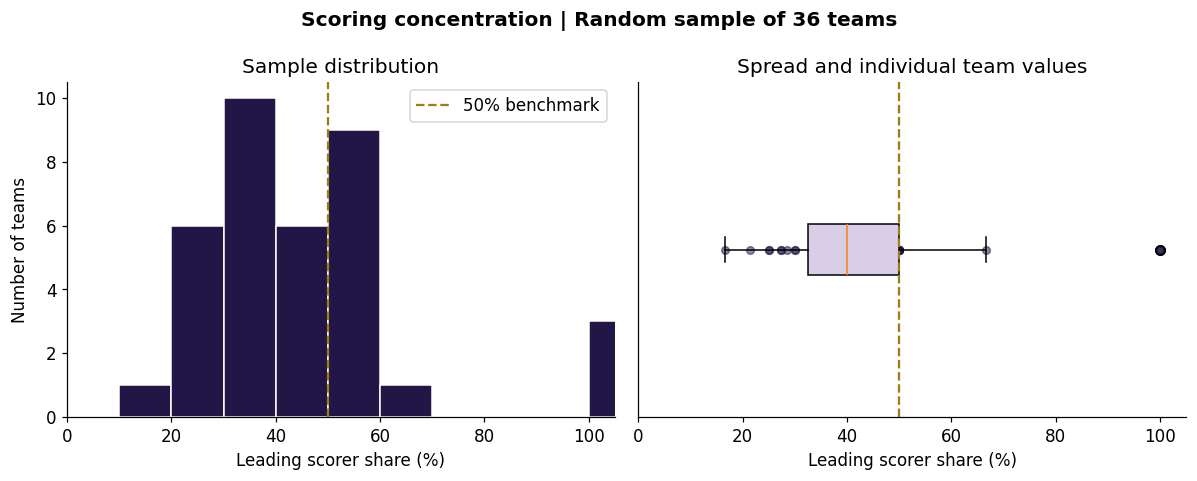

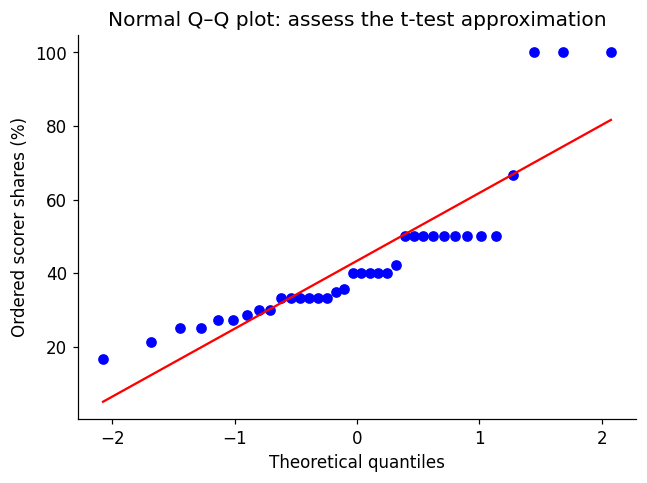

In [4]:
n = len(x)
mean = float(np.mean(x))
sd = float(np.std(x, ddof=1))
se = sd / np.sqrt(n)
q1, median, q3 = np.percentile(x, [25, 50, 75])
summary = pd.Series({'n':n, 'Mean (%)':mean, 'Median (%)':median,
                     'Sample SD (percentage points)':sd, 'Minimum (%)':x.min(),
                     'Q1 (%)':q1, 'Q3 (%)':q3, 'Maximum (%)':x.max(),
                     'IQR (percentage points)':q3-q1})
print(summary.round(4).to_string())
summary.to_csv(OUTPUT / 'descriptive_statistics.csv', header=['Value'])
plt.rcParams.update({'font.size':11, 'axes.spines.top':False, 'axes.spines.right':False})
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].hist(x, bins=np.arange(0, 111, 10), color='#211645', edgecolor='white')
axes[0].axvline(50, color='#A17C15', linestyle='--', label='50% benchmark')
axes[0].set(xlabel='Leading scorer share (%)', ylabel='Number of teams', title='Sample distribution', xlim=(0,105))
axes[0].legend()
axes[1].boxplot(x, vert=False, patch_artist=True, boxprops={'facecolor':'#D8CEE7'})
axes[1].scatter(x, np.ones(n), alpha=.5, color='#211645', s=25)
axes[1].axvline(50, color='#A17C15', linestyle='--')
axes[1].set(xlabel='Leading scorer share (%)', yticks=[], title='Spread and individual team values', xlim=(0,105))
fig.suptitle('Scoring concentration | Random sample of 36 teams', fontweight='bold')
fig.tight_layout()
fig.savefig(OUTPUT / 'distribution.png', dpi=180, bbox_inches='tight')
plt.show()
fig, ax = plt.subplots(figsize=(6,4.5))
stats.probplot(x, dist='norm', plot=ax)
ax.set(title='Normal Q–Q plot: assess the t-test approximation', ylabel='Ordered scorer shares (%)')
fig.tight_layout()
fig.savefig(OUTPUT / 'qq_plot.png', dpi=180, bbox_inches='tight')
plt.show()
print('Sample skewness:', round(stats.skew(x, bias=False), 3))
print('Teams at 100%:', sample.loc[sample.Scorer_share_pct.eq(100), 'Team'].tolist())

## 5. Inferential statistics: 95% confidence interval
Use the Student t interval because the population standard deviation is unknown:

**SE = s / √n; CI = sample mean ± t(0.975, n − 1) × SE.**

Units for the mean and interval endpoints are percent; units for the standard error and differences are percentage points. This is a confidence interval for a mean, not a range expected to contain 95% of individual teams. Under the assumed sampling model, repeated intervals would cover the target mean about 95% of the time. See the finite-frame limitation above.

Mean = 43.3527%; SE = 3.3706 percentage points
t critical = 2.0301; df = 35
95% t confidence interval: [36.5100%, 50.1954%]


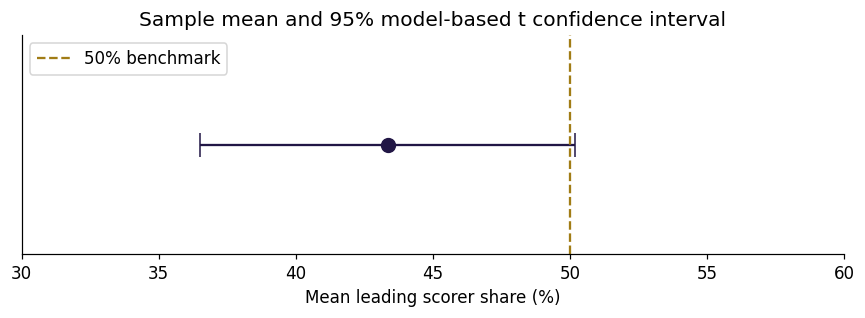

In [5]:
df = n - 1
t_critical = stats.t.ppf(1-ALPHA/2, df)
ci_low, ci_high = stats.t.interval(1-ALPHA, df, loc=mean, scale=se)
print(f'Mean = {mean:.4f}%; SE = {se:.4f} percentage points')
print(f't critical = {t_critical:.4f}; df = {df}')
print(f'95% t confidence interval: [{ci_low:.4f}%, {ci_high:.4f}%]')
fig, ax = plt.subplots(figsize=(8, 3))
ax.errorbar(mean, 0, xerr=[[mean-ci_low],[ci_high-mean]], fmt='o', color='#211645', capsize=8, markersize=9)
ax.axvline(BENCHMARK, color='#A17C15', linestyle='--', label='50% benchmark')
ax.set(xlabel='Mean leading scorer share (%)', yticks=[], xlim=(30,60),
       title='Sample mean and 95% model-based t confidence interval')
ax.legend(loc='upper left')
fig.tight_layout()
fig.savefig(OUTPUT / 'confidence_interval.png', dpi=180, bbox_inches='tight')
plt.show()

## 6. Inferential statistics: two-sided one-sample t-test
**H₀: μ = 50%. H₁: μ ≠ 50%. Alpha = 0.05.**

Here μ is the mean team-level leading-scorer percentage under the working model. We use a one-sample test because we compare one numeric outcome with a meaningful fixed benchmark. A two-sample test is unnecessary; no artificial groups are created.

**t = (sample mean − 50) / (s / √n), with n − 1 degrees of freedom.**

The sample is moderately sized, but the outcome is bounded, right-skewed and has genuine high values. The t-test is approximate; sample size above 30 does not establish normality. The Q–Q plot and the sampling limitations should accompany interpretation, especially when the p-value is near 0.05.

In [6]:
test = stats.ttest_1samp(x, popmean=BENCHMARK, alternative='two-sided')
t_manual = (mean-BENCHMARK)/se
assert np.isclose(test.statistic, t_manual)
reject = test.pvalue < ALPHA
assert reject == (BENCHMARK < ci_low or BENCHMARK > ci_high)
results = {'n':n, 'mean_pct':mean, 'sd_pp':sd, 'se_pp':se,
           'ci_lower_pct':float(ci_low), 'ci_upper_pct':float(ci_high),
           'difference_from_50_pp':mean-BENCHMARK,
           't_statistic':float(test.statistic), 'df':df,
           'p_value_two_sided':float(test.pvalue), 'alpha':ALPHA,
           'reject_null':bool(reject), 'cohens_d':(mean-BENCHMARK)/sd}
pd.Series(results).to_csv(OUTPUT / 'test_results.csv', header=['Value'])
print(f't({df}) = {test.statistic:.4f}; two-sided p = {test.pvalue:.6f}')
print(f'Mean difference = {mean-BENCHMARK:.4f} percentage points')
print(f'One-sample Cohen d = {(mean-BENCHMARK)/sd:.4f}')
print('Decision:', 'Reject H0' if reject else 'Fail to reject H0')

t(35) = -1.9721; two-sided p = 0.056538
Mean difference = -6.6473 percentage points
One-sample Cohen d = -0.3287
Decision: Fail to reject H0


## 7. Written interpretation and conclusion
The random sample of 36 eligible teams had a mean leading-scorer contribution of **43.35%**, a median of **40.00%**, and a sample standard deviation of **20.22 percentage points**. The interquartile range was **17.50 percentage points** (Q1 = 32.50%, Q3 = 50.00%), and values ranged from **16.67% to 100.00%**.

The standard 95% t confidence interval was **36.51% to 50.20%**. The mean was **6.65 percentage points below** the 50% benchmark. However, the two-sided one-sample t-test gave **t(35) = −1.9721, p = 0.05654**. At the preselected 5% significance level, we **fail to reject the null hypothesis**. Under this working model, the sample does not provide sufficient evidence that the average contribution differs from 50%. This does not prove that the mean equals 50%, and a non-significant result is still a valid analysis. We do not switch to a one-sided test after seeing the result.

For the actual finite frame of all 47 eligible teams, the mean is already known: **45.45%**. It is descriptively below 50%; no significance test is needed to establish that finite-frame fact. The textbook test above demonstrates the assessment's inferential method and must not override the full-frame description or be presented as an exact finite-population test.

**Limitations:** The table's provenance is unverified. Team percentages share a tournament and opponents, so independence is imperfect. The sample is drawn without replacement from a small, fully observed frame; the uncorrected t procedure is model-based rather than exact finite-population inference. Discrete low goal totals produce high variability and a right tail; normality is imperfect. Scorer-field interpretation and treatment of own goals depend on the unavailable data dictionary. The analysis cannot establish causation, predict progression, identify player positions, or generalise reliably to other tournaments.

**Practical interpretation:** In this table, a single leading scorer accounts for somewhat less than half of a typical team's goals on average, with substantial variation. Concentration measures how goals are distributed, not how successful or tactically dependent a team is.

## Requirements covered
| Requirement | Implementation |
|---|---|
| Distinct question | Team scoring concentration against a 50% benchmark |
| Wrangling | Text cleanup, numeric conversion, scorer extraction, validation, exclusion |
| Preparation and sampling | Team percentage; defined frame; seeded random sample without replacement |
| Descriptive statistics | Mean, median, SD, quartiles, IQR, range; Python charts |
| Confidence interval | 95% Student t interval with scope caveat |
| t-test | Two-sided one-sample t-test, hypotheses, decision, interpretation |
| Python only | pandas, NumPy, SciPy and Matplotlib; no Excel analysis |

## Appendix: Finite-population sensitivity and inference scope
The 47 eligible teams are fully observed. Their mean is known, so the substantive finite-frame answer is descriptive: **45.45%, below 50%**. Random subsampling demonstrates the assignment's sampling requirement.

The standard one-sample t-test answers a conditional working-model question. It is **not an exact test of this known finite population**. For simple random sampling without replacement, an estimate of the finite-frame mean's standard error is **(s / sqrt(n)) × sqrt(1 − n/N)**. With N = 47 and n = 36, this is substantially smaller than the uncorrected standard error.

For transparency, the calculation below gives an **approximate, finite-population-adjusted t interval**. It is a sensitivity illustration rather than an exact confidence procedure for a small, skewed finite population. It should not be confused with the standard t interval or its p-value. We do not mix one interval with the other procedure's test decision.

The two answers have different targets: the finite table has a known mean below 50%, while the uncorrected model-based t-test does not reject 50% at alpha = 0.05. Generalisation beyond this table needs a justified model or additional representative data. No result establishes causation or tactical dependence.

In [7]:
N = len(eligible)
sampling_fraction = n / N
fpc = np.sqrt(1 - sampling_fraction)
finite_se = se * fpc
finite_ci = stats.t.interval(0.95, n-1, loc=mean, scale=finite_se)
print(f'Sampling fraction: {sampling_fraction:.4f}')
print(f'Finite-population correction: {fpc:.6f}')
print(f'Adjusted estimated SE: {finite_se:.4f} percentage points')
print(f'Approximate finite-frame t interval: {finite_ci[0]:.4f}% to {finite_ci[1]:.4f}%')
print(f'Known full-frame mean: {eligible.Scorer_share_pct.mean():.4f}%')
pd.Series({'N':N,'n':n,'sampling_fraction':sampling_fraction,'fpc':fpc,
           'adjusted_se_pp':finite_se,'approx_lower_pct':finite_ci[0],
           'approx_upper_pct':finite_ci[1],
           'known_frame_mean_pct':eligible.Scorer_share_pct.mean()}).to_csv(
    OUTPUT / 'finite_population_sensitivity.csv', header=['Value'])

Sampling fraction: 0.7660
Finite-population correction: 0.483779
Adjusted estimated SE: 1.6306 percentage points
Approximate finite-frame t interval: 40.0424% to 46.6631%
Known full-frame mean: 45.4465%


## Presentation figures
All plotted evidence below is generated in Python from the same fixed sample or complete eligible frame. The t-test result uses the original uncorrected standard error. The full-frame plot describes all 47 eligible teams and does not represent an independent validation sample.

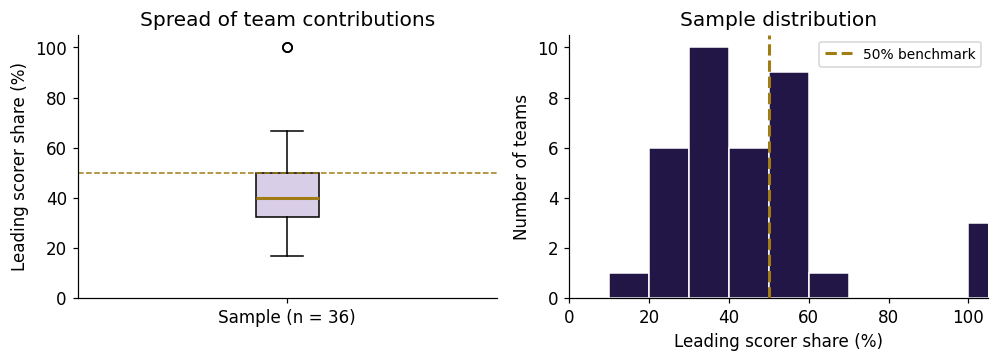

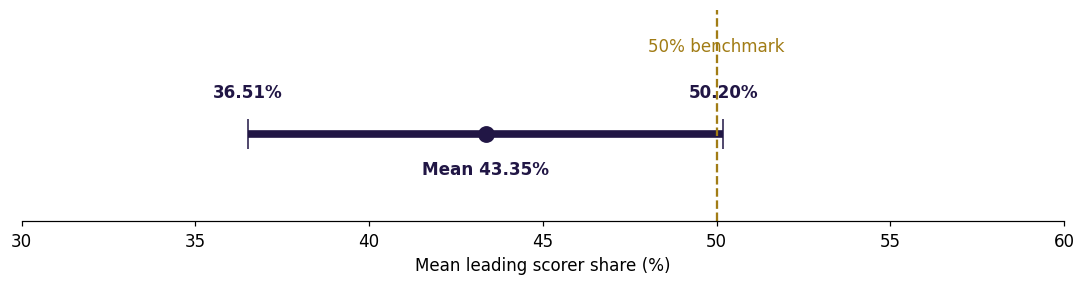

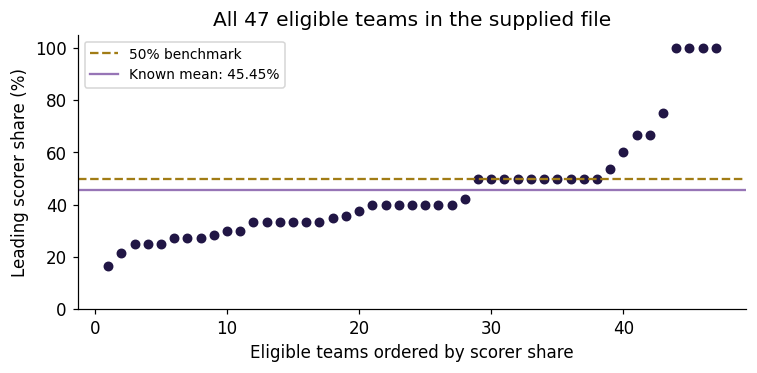

In [8]:
PURPLE = '#211645'
GOLD = '#A17C15'
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.4))
axes[0].boxplot(x, patch_artist=True, boxprops={'facecolor':'#D8CEE7'},
                medianprops={'color':GOLD,'linewidth':2})
axes[0].set(xticks=[1],xticklabels=['Sample (n = 36)'],ylabel='Leading scorer share (%)',ylim=(0,105),title='Spread of team contributions')
axes[0].axhline(50,color=GOLD,linestyle='--',linewidth=1)
axes[1].hist(x,bins=np.arange(0,111,10),color=PURPLE,edgecolor='white')
axes[1].axvline(50,color=GOLD,linestyle='--',linewidth=2,label='50% benchmark')
axes[1].set(xlim=(0,105),xlabel='Leading scorer share (%)',ylabel='Number of teams',title='Sample distribution')
axes[1].legend(fontsize=9)
fig.tight_layout(); fig.savefig(OUTPUT / 'slide_distribution.png',dpi=200,bbox_inches='tight'); plt.show()

fig,ax=plt.subplots(figsize=(10,2.7))
ax.errorbar(mean,0,xerr=[[mean-ci_low],[ci_high-mean]],fmt='o',color=PURPLE,elinewidth=5,capsize=10,markersize=10)
ax.axvline(50,color=GOLD,linestyle='--',linewidth=1.5)
ax.text(50,.67,'50% benchmark',ha='center',color=GOLD)
ax.text(ci_low,.3,f'{ci_low:.2f}%',ha='center',color=PURPLE,fontweight='bold')
ax.text(ci_high,.3,f'{ci_high:.2f}%',ha='center',color=PURPLE,fontweight='bold')
ax.text(mean,-.32,f'Mean {mean:.2f}%',ha='center',color=PURPLE,fontweight='bold')
ax.set(xlim=(30,60),ylim=(-.7,1),yticks=[],xlabel='Mean leading scorer share (%)')
ax.spines['left'].set_visible(False)
fig.tight_layout();fig.savefig(OUTPUT / 'slide_ci.png',dpi=200,bbox_inches='tight');plt.show()

fig,ax=plt.subplots(figsize=(7,3.5))
ordered=np.sort(eligible.Scorer_share_pct.to_numpy())
ax.scatter(np.arange(1,len(ordered)+1),ordered,color=PURPLE,s=30)
ax.axhline(50,color=GOLD,linestyle='--',label='50% benchmark')
ax.axhline(eligible.Scorer_share_pct.mean(),color='#9775B6',label='Known mean: 45.45%')
ax.set(xlabel='Eligible teams ordered by scorer share',ylabel='Leading scorer share (%)',ylim=(0,105),title='All 47 eligible teams in the supplied file')
ax.legend(fontsize=9,loc='upper left')
fig.tight_layout();fig.savefig(OUTPUT / 'slide_full_frame.png',dpi=200,bbox_inches='tight');plt.show()

# Seven-slide presentation script

## Slide 1

Hello, my name is MD Abid Hossain Fahim, student ID s401478, from Sydney Group 19. My analytic question asks whether a team’s leading scorer contributes an average of 50 percent of its goals. I measure each team separately by dividing one leading scorer’s goals by total team goals, then multiplying by 100. Fifty percent is a meaningful benchmark because it represents one player scoring half of the team’s goals. My focus is scoring concentration, which differs from my teammates’ points and defensive-efficiency topics. The supplied table is labelled for the 2026 World Cup, but its original source and whether it represents actual or simulated results are unverified.

## Slide 2

I completed all wrangling in Python using pandas. First, I cleaned text and converted the numeric fields. I verified matches played against wins, draws and losses, goal difference against goals for minus goals against, and points against three times wins plus draws. These checks passed for all 48 teams. Next, I extracted the final goal tally from the top-scorer field. Where multiple names appear, I interpret that number as the individual tally shared by the tied leaders. I did not add their goals together. Finally, I calculated each team’s percentage. Panama scored zero goals, so its share is undefined rather than zero. Excluding Panama leaves 47 eligible teams. These checks establish internal consistency, not authenticity.

## Slide 3

The finite sampling frame consists of the 47 teams that scored at least one goal. My unit of analysis is one team. I used simple random sampling without replacement to select 36 teams, fixing the seed at 401478 so the result can be reproduced. Every eligible team had the same chance of selection, and each team receives equal weight in the average. I kept the original seed and sample rather than searching for a significant result. A sample above thirty is a practical choice, not a guarantee of normality or statistical power. Since all 47 eligible records are available, their mean can be calculated directly. Subsampling demonstrates the assignment requirement. The standard t-test is therefore presented as a conditional working-model exercise, with its finite-population limitation stated explicitly.

## Slide 4

The sample mean is 43.35 percent, with a median of 40 percent. The sample standard deviation is 20.22 percentage points, showing substantial variation between teams. The boxplot and histogram use the same sample. Shares range from 16.67 percent to 100 percent, and the interquartile range is 17.5 percentage points. The right tail is visible, so a normal model is only an approximation. Values of 100 percent are plausible when one player scores all of a team’s goals. I retained those values rather than deleting them as outliers. Percentages based on low team goal totals are also more discrete and variable. These figures describe the distribution; they do not establish tactical dependence or team quality.

## Slide 5

I calculated a 95 percent Student t confidence interval because the population standard deviation is unknown. The standard error is the sample standard deviation divided by the square root of 36, which gives 3.3706 percentage points. Using 35 degrees of freedom gives an interval from 36.51 to 50.20 percent. The interval contains the 50 percent benchmark. This is an interval for the mean under the working model, not a range containing 95 percent of teams. It also does not mean there is a 95 percent probability that a fixed mean lies in this realised interval. No finite-population correction is included in this standard calculation. The report separately shows an approximate finite-population-adjusted interval of 40.04 to 46.66 percent and explains why these are different inferential procedures.

## Slide 6

My null hypothesis is that the mean leading-scorer share equals 50 percent. The alternative is that it differs from 50 percent, so this is a two-sided one-sample t-test. The test statistic is minus 1.9721 with 35 degrees of freedom. SciPy gives a p-value of 0.05654. At the preselected five percent significance level, I fail to reject the null hypothesis. This does not prove equality or establish that there is no meaningful difference. The observed mean is 6.65 percentage points below the benchmark, and the standardised one-sample effect size is minus 0.329. Unlike the demonstration’s two-group analysis, this task has one sample, so a test comparing two group variances is unnecessary. I did not change to a one-sided test after seeing the result.

## Slide 7

My conclusion has two parts. Under the standard working-model t-test, there is insufficient evidence of a difference from 50 percent at the five percent level. Separately, the complete finite dataset has a known mean of 45.45 percent, which is descriptively below 50 percent. The chart shows all 47 eligible teams ordered by their contribution share. This is a full-frame description, not an independent validation sample. Since 36 of 47 teams were sampled without replacement, finite-population effects are substantial. The report includes a sensitivity calculation, and I do not combine that adjusted interval with the uncorrected t-test decision. Shared opponents and the bounded, skewed percentages also limit inference. The analysis describes concentration, not causation or tactical dependence. A non-significant model-based test remains a valid finding and should be reported honestly.